In [10]:
from gurobipy import Model, GRB, quicksum
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Data: Supplier information, cost per unit (c_jk), and maximum supply capacity (s_jk)
suppliers = ['Supplier1', 'Supplier2', 'Supplier3']
resources = ['Toilet Paper', 'Liquid Soap', 'Detergent', 'Cloths', 
             'Toothpaste', 'Toothbrushes', 'Sanitary Pads', 'Shampoo']

# Cost and maximum supply capacity for each supplier and resource
cost_per_unit = {
    ('Supplier1', 'Toilet Paper'): (0.80, 150),
    ('Supplier1', 'Liquid Soap'): (6.40, 25),
    ('Supplier1', 'Detergent'): (6.80, 20),
    ('Supplier1', 'Cloths'): (10.00, 10),
    ('Supplier1', 'Toothpaste'): (2.60, 50),
    ('Supplier1', 'Toothbrushes'): (0.80, 50),
    ('Supplier1', 'Sanitary Pads'): (0.20, 150),
    ('Supplier1', 'Shampoo'): (2.30, 20),
    ('Supplier2', 'Toilet Paper'): (0.95, 100),
    ('Supplier2', 'Liquid Soap'): (3.98, 15),
    ('Supplier2', 'Detergent'): (4.60, 10),
    ('Supplier2', 'Cloths'): (11.00, 10),
    ('Supplier2', 'Toothpaste'): (3.00, 60),
    ('Supplier2', 'Toothbrushes'): (0.85, 60),
    ('Supplier2', 'Sanitary Pads'): (0.18, 100),
    ('Supplier2', 'Shampoo'): (1.20, 20),
    ('Supplier3', 'Toilet Paper'): (0.84, 70),
    ('Supplier3', 'Liquid Soap'): (5.50, 30),
    ('Supplier3', 'Detergent'): (7.50, 15),
    ('Supplier3', 'Cloths'): (10.50, 15),
    ('Supplier3', 'Toothpaste'): (2.80, 30),
    ('Supplier3', 'Toothbrushes'): (0.82, 30),
    ('Supplier3', 'Sanitary Pads'): (0.15, 100),
    ('Supplier3', 'Shampoo'): (3.00, 30)
}

# Minimum required quantities as a dataset for a shelter housing 20 people for one month
minimum_quantities = {
    'Toilet Paper': 200,
    'Liquid Soap': 40,
    'Detergent': 30,
    'Cloths': 20,
    'Toothpaste': 100,
    'Toothbrushes': 100,
    'Sanitary Pads': 300,
    'Shampoo': 40
}

Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i9-13900H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 33 rows, 24 columns and 72 nonzeros
Model fingerprint: 0xa7b10d4f
Coefficient statistics:
  Matrix range     [1e-01, 1e+01]
  Objective range  [1e-01, 1e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+01, 2e+03]
Presolve removed 24 rows and 0 columns
Presolve time: 0.02s
Presolved: 9 rows, 24 columns, 48 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    2.0527912e+02   1.350472e+02   0.000000e+00      0s
       8    1.2248000e+03   0.000000e+00   0.000000e+00      0s

Solved in 8 iterations and 0.03 seconds (0.00 work units)
Optimal objective  1.224800000e+03
Purchase 150.0 units of Toilet Paper from Supplier1
Purchase 50.0 units of Toilet Paper from Supplier3
Purchase 15.0 units of Liquid Soap from 

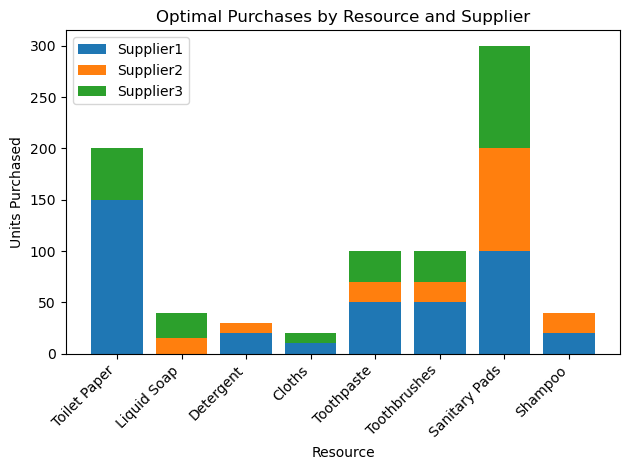

In [12]:
# Create a new model
m = Model("resource_optimization")

# Decision Variables
x = {}
for r in resources:
    for s in suppliers:
        x[(r, s)] = m.addVar(name=f"x_{r}_{s}")

# Objective: Minimize cost
m.setObjective(quicksum(x[r, s] * cost_per_unit[s, r][0] for r in resources for s in suppliers), GRB.MINIMIZE)

# Constraints
# Minimum requirements
for r in resources:
    m.addConstr(quicksum(x[r, s] for s in suppliers) >= minimum_quantities[r], name=f"min_req_{r}")

# Budget
m.addConstr(quicksum(x[r, s] * cost_per_unit[s, r][0] for r in resources for s in suppliers) <= 2000, name=f"budget_{s}")

# Maximum supply limit per item from each supplier
for r in resources:
    for s in suppliers:
        m.addConstr(x[r, s] <= cost_per_unit[s, r][1], name=f"max_supply_{r}_{s}")

# Solve
m.optimize()

# Print solution
if m.status == GRB.OPTIMAL:
    for r in resources:
        for s in suppliers:
            if x[r, s].x > 0:
                print(f"Purchase {x[r, s].x} units of {r} from {s}")
else:
    print("No feasible solution found")
    
supplier_totals = {s: [] for s in suppliers}

for r in resources:
    for s in suppliers:
        supplier_totals[s].append(x[r, s].x)

bottom = np.zeros(len(resources))

plt.figure()
for s in suppliers:
    plt.bar(resources, supplier_totals[s], bottom=bottom, label=s)
    bottom += np.array(supplier_totals[s])

plt.xlabel("Resource")
plt.ylabel("Units Purchased")
plt.title("Optimal Purchases by Resource and Supplier")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Random Cost Structure
What if the cost for each product from these suppliers was not exactly known, but we had an idea of the lower and upper bound for these values?

In [32]:
base_cost = {
    ('Supplier1', 'Toilet Paper'): (0.80),
    ('Supplier1', 'Liquid Soap'): (6.40),
    ('Supplier1', 'Detergent'): (6.80),
    ('Supplier1', 'Cloths'): (10.00),
    ('Supplier1', 'Toothpaste'): (2.60),
    ('Supplier1', 'Toothbrushes'): (0.80),
    ('Supplier1', 'Sanitary Pads'): (0.20),
    ('Supplier1', 'Shampoo'): (2.30),
    ('Supplier2', 'Toilet Paper'): (0.95),
    ('Supplier2', 'Liquid Soap'): (3.98),
    ('Supplier2', 'Detergent'): (4.60),
    ('Supplier2', 'Cloths'): (11.00),
    ('Supplier2', 'Toothpaste'): (3.00),
    ('Supplier2', 'Toothbrushes'): (0.85),
    ('Supplier2', 'Sanitary Pads'): (0.18),
    ('Supplier2', 'Shampoo'): (1.20),
    ('Supplier3', 'Toilet Paper'): (0.84),
    ('Supplier3', 'Liquid Soap'): (5.50),
    ('Supplier3', 'Detergent'): (7.50),
    ('Supplier3', 'Cloths'): (10.50),
    ('Supplier3', 'Toothpaste'): (2.80),
    ('Supplier3', 'Toothbrushes'): (0.82),
    ('Supplier3', 'Sanitary Pads'): (0.15),
    ('Supplier3', 'Shampoo'): (3.00)
}

random_cost = {
    ('Supplier1', 'Toilet Paper'): np.random.uniform(0.8-0.2, 0.8+0.2),
    ('Supplier1', 'Liquid Soap'): np.random.uniform(6.40-0.2, 6.40+0.2), 
    ('Supplier1', 'Detergent'): np.random.uniform(6.80-0.2, 6.80+0.2) ,
    ('Supplier1', 'Cloths'): np.random.uniform(10.0-0.2, 10.0+0.2) ,
    ('Supplier1', 'Toothpaste'): np.random.uniform(2.60-0.2, 2.60+0.2), 
    ('Supplier1', 'Toothbrushes'): np.random.uniform(0.80-0.2, 0.80+0.2), 
    ('Supplier1', 'Sanitary Pads'): np.random.uniform(0.20-0.2, 0.20+0.2) ,
    ('Supplier1', 'Shampoo'): np.random.uniform(2.30-0.2, 2.30+0.2), 
    ('Supplier2', 'Toilet Paper'): np.random.uniform(0.95-0.2, 0.95+0.2), 
    ('Supplier2', 'Liquid Soap'): np.random.uniform(3.98-0.2, 3.98+0.2), 
    ('Supplier2', 'Detergent'): np.random.uniform(4.60-0.2, 4.60+0.2), 
    ('Supplier2', 'Cloths'): np.random.uniform(11.0-0.2, 11.0+0.2), 
    ('Supplier2', 'Toothpaste'): np.random.uniform(3.00-0.2, 3.00+0.2),
    ('Supplier2', 'Toothbrushes'): np.random.uniform(0.85-0.2, 0.85+0.2),
    ('Supplier2', 'Sanitary Pads'): np.random.uniform(0.18-0.2, 0.18+0.2),
    ('Supplier2', 'Shampoo'): np.random.uniform(1.20-0.2, 1.20+0.2),
    ('Supplier3', 'Toilet Paper'): np.random.uniform(0.84-0.2, 0.84+0.2),
    ('Supplier3', 'Liquid Soap'): np.random.uniform(5.50-0.2, 5.50+0.2),
    ('Supplier3', 'Detergent'): np.random.uniform(7.50-0.2, 7.50+0.2),
    ('Supplier3', 'Cloths'): np.random.uniform(10.50-0.2, 0.50+0.2),
    ('Supplier3', 'Toothpaste'): np.random.uniform(2.80-0.2, 2.80+0.2),
    ('Supplier3', 'Toothbrushes'): np.random.uniform(0.82-0.2, 0.82+0.2),
    ('Supplier3', 'Sanitary Pads'): np.random.uniform(0.15-0.2, 0.15+0.2),
    ('Supplier3', 'Shampoo'): np.random.uniform(3.00-0.2, 3.00+0.2)
}

In [40]:
def sample_all_costs():
    random_cost = {}
    for key, c in base_cost.items():
        random_cost[key] = np.random.uniform(base_cost[key]-0.2, base_cost[key]-0.2)
    return random_cost

Define the optimization problem as a function

In [37]:
def solve_lp(cost):
    m = Model("resource_optimization")
    m.setParam("OutputFlag", 0)

    x = {}
    for r in resources:
        for s in suppliers:
            x[(r, s)] = m.addVar(lb=0, name=f"x_{r}_{s}")

    # Objective (now there is randomness)
    m.setObjective(
        quicksum(x[r, s] * random_cost[s, r]
                 for r in resources for s in suppliers),
        GRB.MINIMIZE
    )

    # Demand constraints 
    for r in resources:
        m.addConstr(
            quicksum(x[r, s] for s in suppliers) >= minimum_quantities[r],
            name=f"demand_{r}"
        )

    # Budget
    m.addConstr(
        quicksum(x[r, s] * random_cost[s, r]
                 for r in resources for s in suppliers) <= 2000
    )

    # Supply limits
    for r in resources:
        for s in suppliers:
            m.addConstr(
                x[r, s] <= cost_per_unit[s, r][1]
            )

    m.optimize()

    if m.status == GRB.OPTIMAL:
        return m.objVal
    else:
        return None


## Monte Carlo Looping

In [38]:
N = 500
infeasible = 0

for _ in range(N):
    
    random_cost = {
    ('Supplier1', 'Toilet Paper'): np.random.uniform(0.8-0.2, 0.8+0.2),
    ('Supplier1', 'Liquid Soap'): np.random.uniform(6.40-0.2, 6.40+0.2), 
    ('Supplier1', 'Detergent'): np.random.uniform(6.80-0.2, 6.80+0.2) ,
    ('Supplier1', 'Cloths'): np.random.uniform(10.0-0.2, 10.0+0.2) ,
    ('Supplier1', 'Toothpaste'): np.random.uniform(2.60-0.2, 2.60+0.2), 
    ('Supplier1', 'Toothbrushes'): np.random.uniform(0.80-0.2, 0.80+0.2), 
    ('Supplier1', 'Sanitary Pads'): np.random.uniform(0.20-0.2, 0.20+0.2) ,
    ('Supplier1', 'Shampoo'): np.random.uniform(2.30-0.2, 2.30+0.2), 
    ('Supplier2', 'Toilet Paper'): np.random.uniform(0.95-0.2, 0.95+0.2), 
    ('Supplier2', 'Liquid Soap'): np.random.uniform(3.98-0.2, 3.98+0.2), 
    ('Supplier2', 'Detergent'): np.random.uniform(4.60-0.2, 4.60+0.2), 
    ('Supplier2', 'Cloths'): np.random.uniform(11.0-0.2, 11.0+0.2), 
    ('Supplier2', 'Toothpaste'): np.random.uniform(3.00-0.2, 3.00+0.2),
    ('Supplier2', 'Toothbrushes'): np.random.uniform(0.85-0.2, 0.85+0.2),
    ('Supplier2', 'Sanitary Pads'): np.random.uniform(0.18-0.2, 0.18+0.2),
    ('Supplier2', 'Shampoo'): np.random.uniform(1.20-0.2, 1.20+0.2),
    ('Supplier3', 'Toilet Paper'): np.random.uniform(0.84-0.2, 0.84+0.2),
    ('Supplier3', 'Liquid Soap'): np.random.uniform(5.50-0.2, 5.50+0.2),
    ('Supplier3', 'Detergent'): np.random.uniform(7.50-0.2, 7.50+0.2),
    ('Supplier3', 'Cloths'): np.random.uniform(10.50-0.2, 0.50+0.2),
    ('Supplier3', 'Toothpaste'): np.random.uniform(2.80-0.2, 2.80+0.2),
    ('Supplier3', 'Toothbrushes'): np.random.uniform(0.82-0.2, 0.82+0.2),
    ('Supplier3', 'Sanitary Pads'): np.random.uniform(0.15-0.2, 0.15+0.2),
    ('Supplier3', 'Shampoo'): np.random.uniform(3.00-0.2, 3.00+0.2)
    }
    
    result = solve_lp(random_cost)
    if result is None:
        infeasible += 1
    else:
        costs.append(result)

print(f"Infeasible runs: {infeasible} / {N}")
print(f"Average cost: {np.mean(costs):.2f}")
print(f"95th percentile cost: {np.percentile(costs, 95):.2f}")


Infeasible runs: 0 / 500
Average cost: 1142.72
95th percentile cost: 1225.17


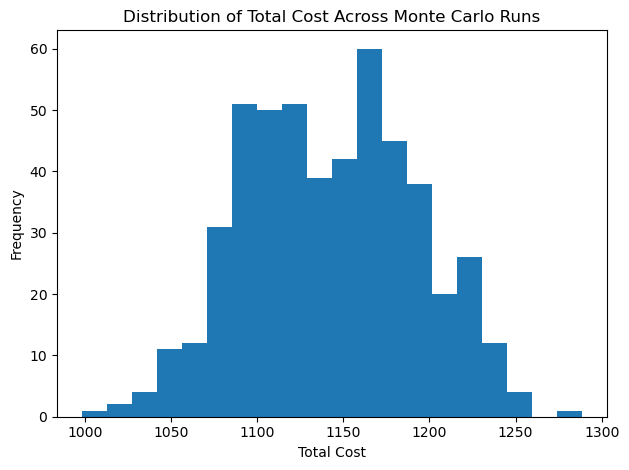

In [43]:
plt.figure()
plt.hist(costs, bins=20)
plt.xlabel("Total Cost")
plt.ylabel("Frequency")
plt.title("Distribution of Total Cost Across Monte Carlo Runs")
plt.tight_layout()
plt.show()